# Kaggle Mushrooms Dataset
Source: https://www.kaggle.com/datasets/dariobaumberger/combined-kaggle-mushrooms-dataset/data

Credit for merge effort: https://github.com/dario-baumberger/combined-kaggle-mushrooms-dataset

---

### Libraries & Packages

In [46]:
# path for photo inventory
from pathlib import Path
import copy

# for opening imagesp
from PIL import Image, UnidentifiedImageError
import re

# plots
import math
import matplotlib.pyplot as plt

# core 
import numpy as np
import pandas as pd

#sklearn
# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

# PyTorch
from torchvision import transforms # image transforms
from torchvision.datasets import ImageFolder # PyTorch image folder loader
from torch.utils.data import Subset
from torch.utils.data import DataLoader # PyTorch batching

# PyTorch model setup
import torch
import torch.nn as nn
from torchvision import models

### Project Paths and Settings

In [2]:
# relative path and image extension
image_folder = Path(r"images")
image_extension = ".webp" # all images are .webp
SEED = 67

In [3]:
# check path for `image` folder to load nested folder structure
print(image_folder.resolve())
print(image_folder.exists())

D:\academic\UCF\2026_summer\Data Mining 2\GroupProject\Images
True


---

# EDA
- Learn structure of image set
- Pre-processing decisions
- Main purpose is to lead into PyTorch ImageFolder setup to flow into train/test splits -> feature extraction -> baseline model -> other models -> comparison

### Table:
- file_path
- folder
- genus
- species
- label_type
- img_number
- width
- height
- aspect_ratio
- valid_image (means PIL can open/read image size)

In [4]:
folders_without_space = [
    class_dir.name
    for class_dir in sorted(image_folder.iterdir())
    if class_dir.is_dir() and " " not in class_dir.name
]

print("folders without space:", len(folders_without_space))
folders_without_space[:50]

folders without space: 4


['Chroogomphus', 'Clavariaceae', 'Clavulinaceae', 'Pleurotus']

In [5]:
# load metadata df directly if it exists
metadata_file = Path("image_metadata.parquet")

if metadata_file.exists():
    df = pd.read_parquet(metadata_file)
    print("loaded metadata:", metadata_file)

# or else create the dataframe and save it
else:

# empty rows list to fill metadata table
    rows = []

    # loop through each folder
    for class_dir in sorted(image_folder.iterdir()):
        if not class_dir.is_dir():
            continue

        # pull folder name and split possible genus/species
        folder = class_dir.name
        folder_parts = folder.split(" ", 1)

        # binomial label: Genus | species
        if len(folder_parts) == 2:
            genus = folder_parts[0]
            species = folder_parts[1]
            label_type = "binomial"

        # single label folders: genus/family/etc. only
        else:
            genus = folder
            species = None
            label_type = "non_binomial"

        # loop through images inside current label folder
        for img_path in sorted(class_dir.glob(f"*{image_extension}")):
            img_number = int(img_path.stem.rsplit("_", 1)[1])

            # try opening image and pulling size metadata
            try:
                with Image.open(img_path) as img:
                    width, height = img.size

                valid_image = True
                aspect_ratio = width / height
            
            # mark image invalid if metadata cannot be read
            except (UnidentifiedImageError, OSError):
                width = None
                height = None
                aspect_ratio = None
                valid_image = False
            
            # add one image row to metadata table
            rows.append({
                "file_path": str(img_path),
                "folder": folder,
                "genus": genus,
                "species": species,
                "label_type": label_type,
                "img_number": img_number,
                "width": width,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "valid_image": valid_image
            })

    # save metadata rows as DataFrame
    df = pd.DataFrame(rows)
    df.to_parquet(metadata_file)
    print("created metadata:", metadata_file)

loaded metadata: image_metadata.parquet


In [6]:
print("total images:", len(df))
print("valid images:", df["valid_image"].sum())
print("invalid images:", (~df["valid_image"]).sum())
print(df["label_type"].value_counts()) #image counts

total images: 195411
valid images: 195411
invalid images: 0
label_type
binomial        195271
non_binomial       140
Name: count, dtype: int64


In [7]:
# checking table for EDA
df = df.sort_values(["folder", "img_number"]).reset_index(drop=True)
df.head()

,file_path,folder,genus,species,label_type,img_number,width,height,aspect_ratio,valid_image
0,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,1,100,100,1.0,True
1,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,2,100,100,1.0,True
2,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,3,100,100,1.0,True
3,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,4,100,100,1.0,True
4,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,5,100,100,1.0,True


### Species / Genus Distribution

This section summarizes how images are distributed between class labels and genus groups.

Each folder is a class label since PyTorch will use the folder names as the target classes. Though, Genus and species are parsed from the folder names for EDA.

The goal is here is to check dataset balance for later preprocessing decisions like stratifiied splits, and evaluation metric choice.

Key questions:
- How many folder-based class labels are present?
- How many genus groups are present?
- Which classes dominate the dataset?
- Which classes are underrepresented?
- Are any labels non-binomial or structurally unusual?
- Should train/test splitting be stratified by class?
- Should evaluation include macro-F1 instead of relying only on accuracy?

In [8]:
# Make tables for separate analysis between species and genus

# makes df with genus, species, label, and adds image count
species_counts = (
    df.groupby("folder")
    .agg(
        genus=("genus", "first"),
        species=("species", "first"),
        label_type=("label_type", "first"),
        image_count=("folder", "size")
    )
    .reset_index()
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# makes df with genus, species_count, and adds image count
genus_counts = (
    df.groupby("genus")
    .agg(
        species_count=("folder", "nunique"),
        image_count=("folder", "size")
    )
    .reset_index()
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# totals
print("folder/class labels:", species_counts["folder"].nunique())
print("binomial labels:", (species_counts["label_type"] == "binomial").sum())
print("non-binomial labels:", (species_counts["label_type"] == "non_binomial").sum())
print("unique species labels:", species_counts["species"].nunique())
print("unique genus labels:", genus_counts["genus"].nunique())

folder/class labels: 555
binomial labels: 551
non-binomial labels: 4
unique species labels: 522
unique genus labels: 216


In [9]:
# checking the 29 gap between species and folder/class labels
repeated_species_names = (
    species_counts[species_counts["species"].notna()]
    .groupby("species")
    .agg(
        folder_count=("folder", "nunique"),
        folders=("folder", lambda x: list(x))
    )
    .reset_index()
    .query("folder_count > 1")
    .sort_values("folder_count", ascending=False)
)

repeated_species_names

,species,folder_count,folders
440,squamosus,3,"[Cerioporus squamosus, Sarcodon squamosus, Pol..."
301,nuda,3,"[Clitocybe nuda, Collybia nuda, Lepista nuda]"
6,adusta,2,"[Bjerkandera adusta, Russula adusta]"
298,nidulans,2,"[Phyllotopsis nidulans, Hapalopilus nidulans]"
482,tubaeformis,2,"[Craterellus tubaeformis, Picipes tubaeformis]"
472,tomentosus,2,"[Phellodon tomentosus, Suillus tomentosus]"
466,tabescens,2,"[Armillaria tabescens, Desarmillaria tabescens]"
409,rufescens,2,"[Geastrum rufescens, Hydnum rufescens]"
402,rubellus,2,"[Cortinarius rubellus, Hortiboletus rubellus]"
380,pyriforme,2,"[Apioperdon pyriforme, Lycoperdon pyriforme]"


- same species names can belong to different genus ; general knowledge supporting our target being full label instead of further splitting folder layout for given genus -> species

In [10]:
# distribution check via simple statistics
distribution_summary = pd.DataFrame({
    "species": [
        species_counts["image_count"].min(),
        species_counts["image_count"].max(),
        species_counts["image_count"].median(),
        species_counts["image_count"].mean(),
        species_counts["image_count"].mode().iloc[0]
    ],
    "genus": [
        genus_counts["image_count"].min(),
        genus_counts["image_count"].max(),
        genus_counts["image_count"].median(),
        genus_counts["image_count"].mean(),
        genus_counts["image_count"].mode().iloc[0]
    ]
}, index=["min", "max", "median", "mean", "mode"])

distribution_summary

,species,genus
min,12.000000,25.000000
max,5823.000000,14293.000000
median,295.000000,390.000000
mean,352.091892,904.680556
mode,28.000000,31.000000


- Genus is expected to be larger since every species belongs to a genus, aside from a 4 non-binomial labels

In [11]:
# species level

# which species have most images
display(species_counts.head(5))

# which species have least images
species_counts.sort_values("image_count", ascending=True).head(5)

,folder,genus,species,label_type,image_count
0,Xanthoria parietina,Xanthoria,parietina,binomial,5823
1,Fomes fomentarius,Fomes,fomentarius,binomial,5245
2,Fomitopsis pinicola,Fomitopsis,pinicola,binomial,5090
3,Amanita muscaria,Amanita,muscaria,binomial,4989
4,Laetiporus sulphureus,Laetiporus,sulphureus,binomial,2958


,folder,genus,species,label_type,image_count
554,Rubroboletus pulcherrimus,Rubroboletus,pulcherrimus,binomial,12
553,Amanita fuliginea,Amanita,fuliginea,binomial,13
552,Amanita viscidolutea,Amanita,viscidolutea,binomial,13
551,Boletus pulcherrimus,Boletus,pulcherrimus,binomial,14
550,Amanita rubrovolvata,Amanita,rubrovolvata,binomial,14


In [12]:
# genus level

# which genus have most species
display(
    genus_counts
    .sort_values("species_count", ascending=False)
    [["genus", "species_count"]]
    .head(5)
)

# which genus have most images
display(
    genus_counts
    .sort_values("image_count", ascending=False)
    [["genus", "image_count"]]
    .head(5)
    )

# which genus have least images
(genus_counts
 .sort_values("image_count", ascending=True)
 [["genus", "image_count"]]
 .head(5)
 )

,genus,species_count
0,Amanita,65
3,Cortinarius,32
5,Lactarius,19
9,Tricholoma,18
8,Russula,17


,genus,image_count
0,Amanita,14293
1,Fomitopsis,6944
2,Xanthoria,5823
3,Cortinarius,5541
4,Fomes,5245


,genus,image_count
215,Neonothopanus,25
214,Kalaharituber,25
212,Podostroma,26
213,Pleurocybella,26
210,Pholiotina,28


- Can see a steep drop off in image count distribution 

- Explaining: 
    - mean - median positive difference trend
    - high max 
    - Bottom images are closer together in value; flatter since it is close to mode.

- Distribution will have a steep fall off, but still high numbers until it baselines somewhere in the 100's and has another drop to another baseline somewhere in the 10's

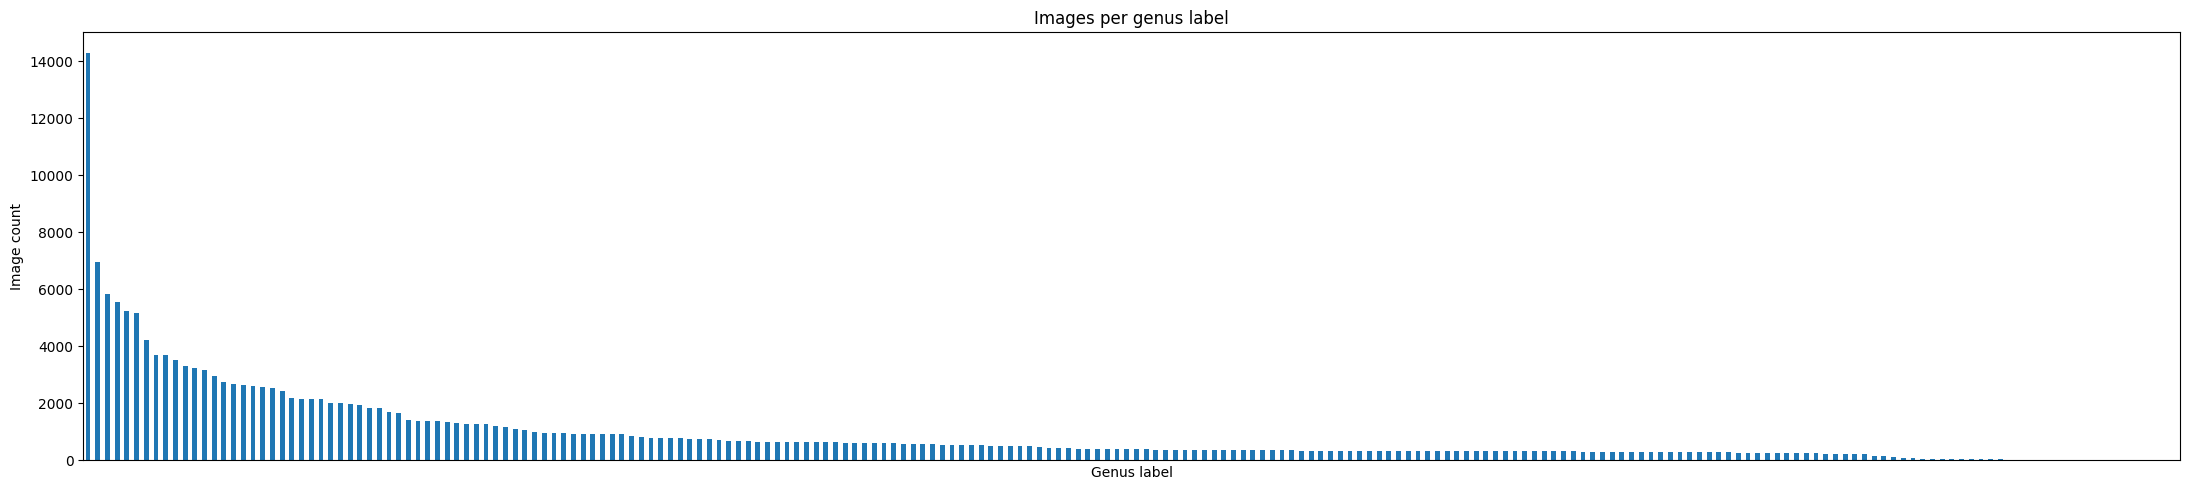

In [13]:
# genus counts
species_plot_counts = df["genus"].value_counts()

# plot image count per genus label
species_plot_counts.plot(
    kind="bar",
    figsize=(22, 5),
    title="Images per genus label"
)

# labels and display
plt.xlabel("Genus label")
plt.ylabel("Image count")
plt.xticks([])  # hide noisy species names
plt.tight_layout()
plt.show()

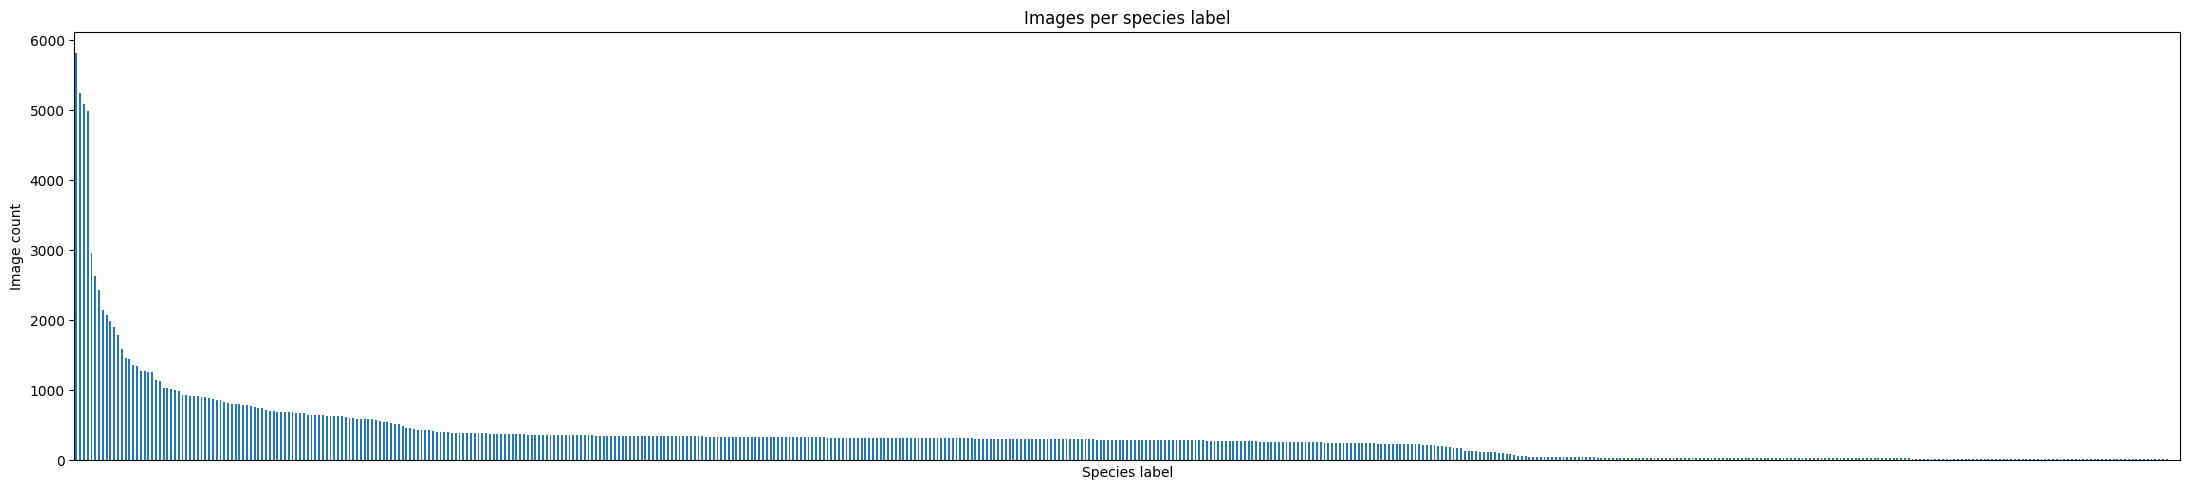

In [14]:
# species counts
species_plot_counts = df["folder"].value_counts()

# plot image count per species label
species_plot_counts.plot(
    kind="bar",
    figsize=(22, 5),
    title="Images per species label"
)

# labels and display
plt.xlabel("Species label")
plt.ylabel("Image count")
plt.xticks([])  # hide noisy species names
plt.tight_layout()
plt.show()

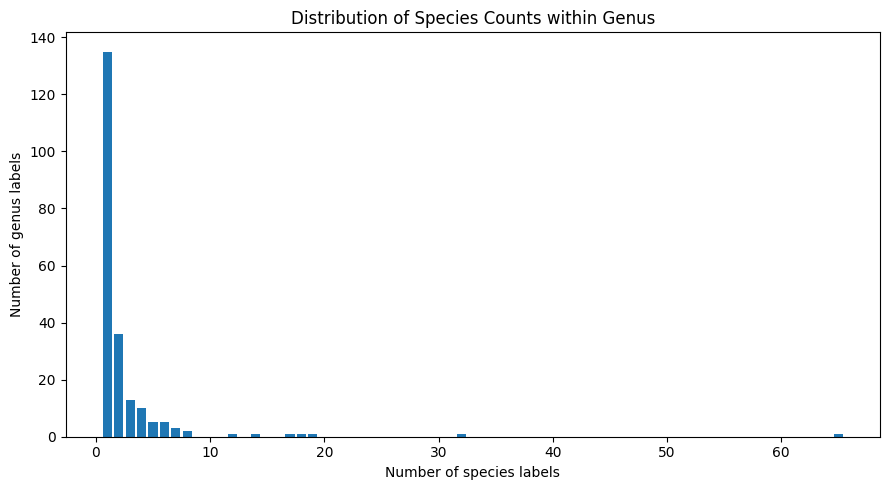

In [15]:
# count how many genus labels have 1, 2, 3, ... species labels
species_per_genus_distribution = (
    genus_counts["species_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# clean column names for plotting
species_per_genus_distribution.columns = [
    "species_labels_per_genus",
    "genus_count"
]

# slot for plot 
plt.figure(figsize=(9, 5))

# bar plot x and y for distribution check
plt.bar(
    species_per_genus_distribution["species_labels_per_genus"],
    species_per_genus_distribution["genus_count"]
)

# labels and display
plt.title("Distribution of Species Counts within Genus")
plt.xlabel("Number of species labels")
plt.ylabel("Number of genus labels")
plt.tight_layout()
plt.show()

### Image size checks

- summary of width/height/aspect-ratio
- unique size combinations, cumulative value for each combination for PyTorch transform; necessity check
- frequency of images distribution by unique sizes

In [16]:
# simple summary statistics
size_metric_summary = (
    df[["width", "height", "aspect_ratio"]]
    .agg(["min", "max", "median", "mean", "std"])
)

# add mode calculation
size_metric_summary.loc["mode"] = (
    df[["width", "height", "aspect_ratio"]]
    .mode()
    .iloc[0]
)

size_metric_summary

,width,height,aspect_ratio
min,90.000000,90.000000,0.252000
max,500.000000,500.000000,4.385965
median,333.000000,331.000000,1.000000
mean,340.259208,326.220458,1.070949
std,123.922141,115.129194,0.274597
mode,224.000000,224.000000,1.000000


In [17]:
# count each unique width/height/aspect-ratio combo
size_combinations = (
    df.groupby(["width", "height", "aspect_ratio"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# percent of total images for each size combo
size_combinations["percent_total"] = (
    size_combinations["image_count"] / len(df) * 100
)

# running percent to see how quickly common sizes add up
size_combinations["cumulative_percent"] = (
    size_combinations["percent_total"].cumsum()
)

size_combinations

,width,height,aspect_ratio,image_count,percent_total,cumulative_percent
0,224,224,1.000000,83614,42.788789,42.788789
1,500,375,1.333333,31288,16.011381,58.800170
2,375,500,0.750000,28257,14.460291,73.260461
3,500,333,1.501502,9216,4.716214,77.976675
4,281,500,0.562000,3529,1.805937,79.782612
...,...,...,...,...,...,...
1139,500,175,2.857143,1,0.000512,99.997953
1140,500,174,2.873563,1,0.000512,99.998465
1141,500,170,2.941176,1,0.000512,99.998977
1142,500,150,3.333333,1,0.000512,99.999488


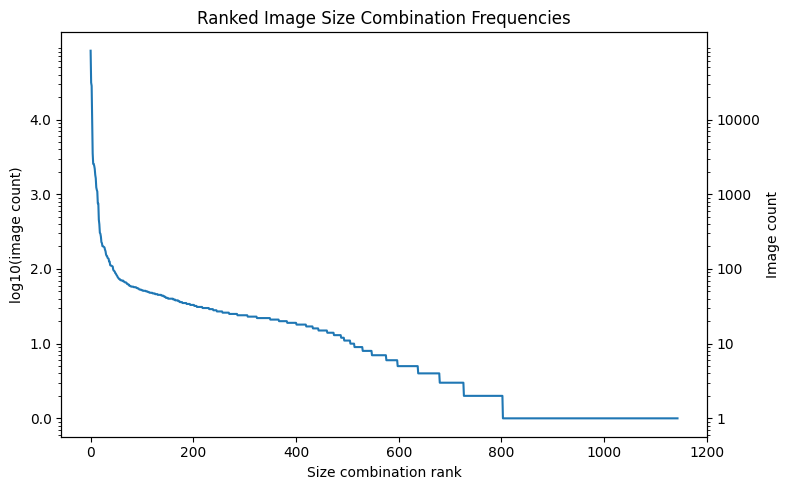

In [18]:
# raw values for log interpretation
tick_values = [1, 10, 100, 1000, 10000, 100000]
tick_values = [x for x in tick_values if x <= size_combinations["image_count"].max()]

# slot for plot 
fig, ax = plt.subplots(figsize=(8, 5))

# plot size combinations ranked by image count
ax.plot(size_combinations["image_count"].values)

# left axis as log10 values
ax.set_yscale("log")
ax.set_yticks(tick_values)
ax.set_yticklabels([round(math.log10(x), 2) for x in tick_values])
ax.set_ylabel("log10(image count)")

# right axis as raw image counts
ax_right = ax.twinx()
ax_right.set_yscale("log")
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(tick_values)
ax_right.set_yticklabels([str(x) for x in tick_values])
ax_right.set_ylabel("Image count")

# labels and display
ax.set_title("Ranked Image Size Combination Frequencies")
ax.set_xlabel("Size combination rank")
plt.tight_layout()
plt.show()

- Original images vary in size, PyTorch will need to handle resizing during loading

- Making up 100% of the image count, most of the images are in the top 5 combinations, about 80% of the images. After which it begins to fall off rapidly and then gradually decline with a high number of unique cominbations for 1 image. Like 500 x 499, 500 x 498, etc.

---

## Visual Checks
This section looks directly at images to confirm EDA findings before moving on

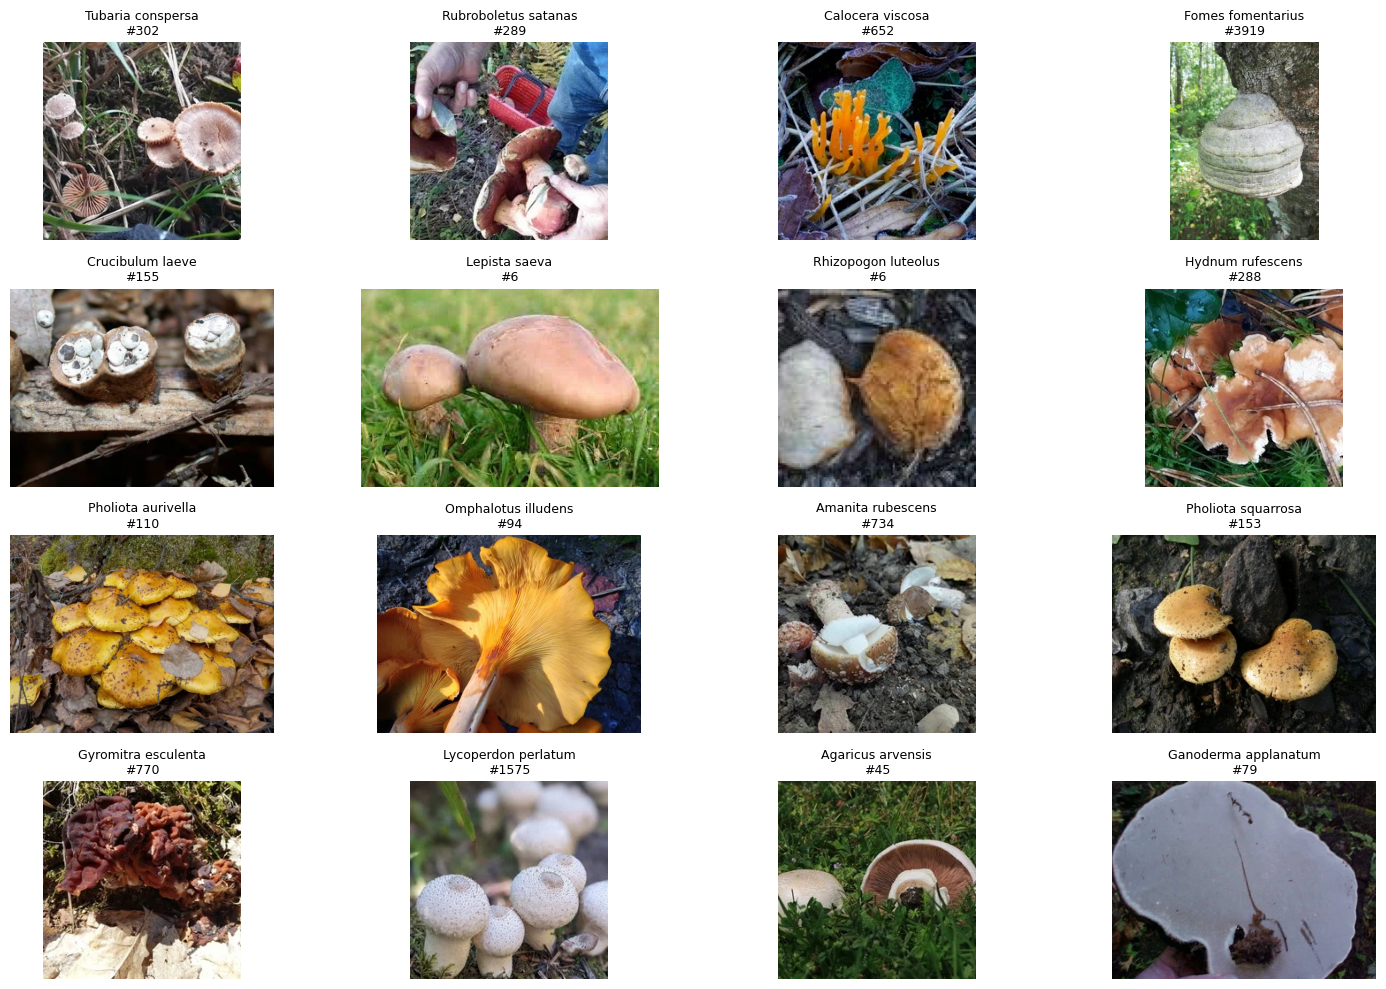

In [19]:
# random sample 16 images
sample_images = df.sample(n=16, random_state=SEED)

# create emtpy slots for images
fig, axes = plt.subplots(4, 4, figsize=(15, 10))
axes = axes.flatten()

# put images into slots with file name
for ax, (_, row) in zip(axes, sample_images.iterrows()):
    img = Image.open(row["file_path"])
    ax.imshow(img)
    ax.set_title(f"{row['folder']}\n#{row['img_number']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---

### Early modeling decision:
Images will contain backgrounds for model to learn since mushrooms grow in different climates and different substrates (different tree types, grassy, mulch, leafy, environments like hilly, mountainous, river etc.)

### Going towards ImageFolder
- The class label for modeling will be the folder label, not genus/species separated.
- Will use resnet18 pretrained imagenet 1k for standard image features like edges, textures, shapes, etc.
- Transforms will standardize image shape during loading, as well as normalization with mean and std for pretrained model expectations (according to: https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html).
- Will have pre-training clustering visuals of the full dataset before getting trained to our data.
- Train/test split must account for imbalance ; stratified.
- Label noise is expected and will be audited later using embeddings/clustering/model disagreement.

---

### Transforms, and load

In [20]:
# baseline transform for pretrained ResNet18
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load folder-labeled image dataset through PyTorch
image_dataset = ImageFolder(
    root=image_folder,
    transform=baseline_transform
)

# compare PyTorch load against metadata table
# to check if image loader sees the same number of images and folders
print("ImageFolder images:", len(image_dataset))
print("DataFrame images:", len(df))

print("ImageFolder classes:", len(image_dataset.classes))
print("DataFrame folder labels:", df["folder"].nunique())

ImageFolder images: 195411
DataFrame images: 195411
ImageFolder classes: 555
DataFrame folder labels: 555


---

### Pre-train clustering
- Check how generic ImageNet features group species
- Baseline clusters

In [22]:
# device and class count setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(image_dataset.classes)

print("device:", device)
print("number of classes:", num_classes)

device: cuda
number of classes: 555


In [23]:
# raw pretrained ResNet18 before mushroom training
raw_model = models.resnet18(weights="DEFAULT")
raw_model = raw_model.to(device)

# feature extractor removes final classification layer
raw_feature_extractor = nn.Sequential(
    *list(raw_model.children())[:-1]
)

raw_feature_extractor = raw_feature_extractor.to(device)
raw_feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

### Feature Extraction

In [24]:
#create a DataLoader for the entire dataset to extract features
batch_size = 64

feature_loader = DataLoader(
    image_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

### Embeddings

In [25]:
#extract features for all images in the dataset
embeddings = []
labels = []

with torch.no_grad():

    for images, target in feature_loader:

        images = images.to(device)

        features = raw_feature_extractor(images)

        # (batch,512,1,1) -> (batch,512)
        features = torch.flatten(features, 1)

        embeddings.append(features.cpu())
        labels.append(target)

In [26]:
# concatenate all embeddings and labels into single tensors
embeddings = torch.cat(embeddings, dim=0)
labels = torch.cat(labels, dim=0)

print(embeddings.shape)
print(labels.shape)

torch.Size([195411, 512])
torch.Size([195411])


In [27]:
#save embeddings and labels to a file for later use
torch.save(
    {
        "embeddings": embeddings,
        "labels": labels
    },
    "resnet18_embeddings.pt"
)

In [28]:
embedding_df = pd.DataFrame(embeddings.numpy())
embedding_df["label"] = labels.numpy()

species_embeddings = embedding_df.groupby("label").mean()
print(species_embeddings.shape)

(555, 512)


### PCA

In [ ]:
pca = PCA(n_components=2, random_state=SEED)

embedding_pca = pca.fit_transform(species_embeddings)

### UMAP

In [ ]:
reducer = umap.UMAP(
    n_components=2,
    random_state=SEED
)

embedding_umap = reducer.fit_transform(species_embeddings)

c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
cluster_model = AgglomerativeClustering(
    n_clusters=20
)

agg_clusters = cluster_model.fit_predict(species_embeddings)

### KMeans

In [ ]:
kmeans = KMeans(
    n_clusters=20,
    random_state=SEED,
    n_init=10,
)

kmeans_clusters = kmeans.fit_predict(species_embeddings)

c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


### Dendogram

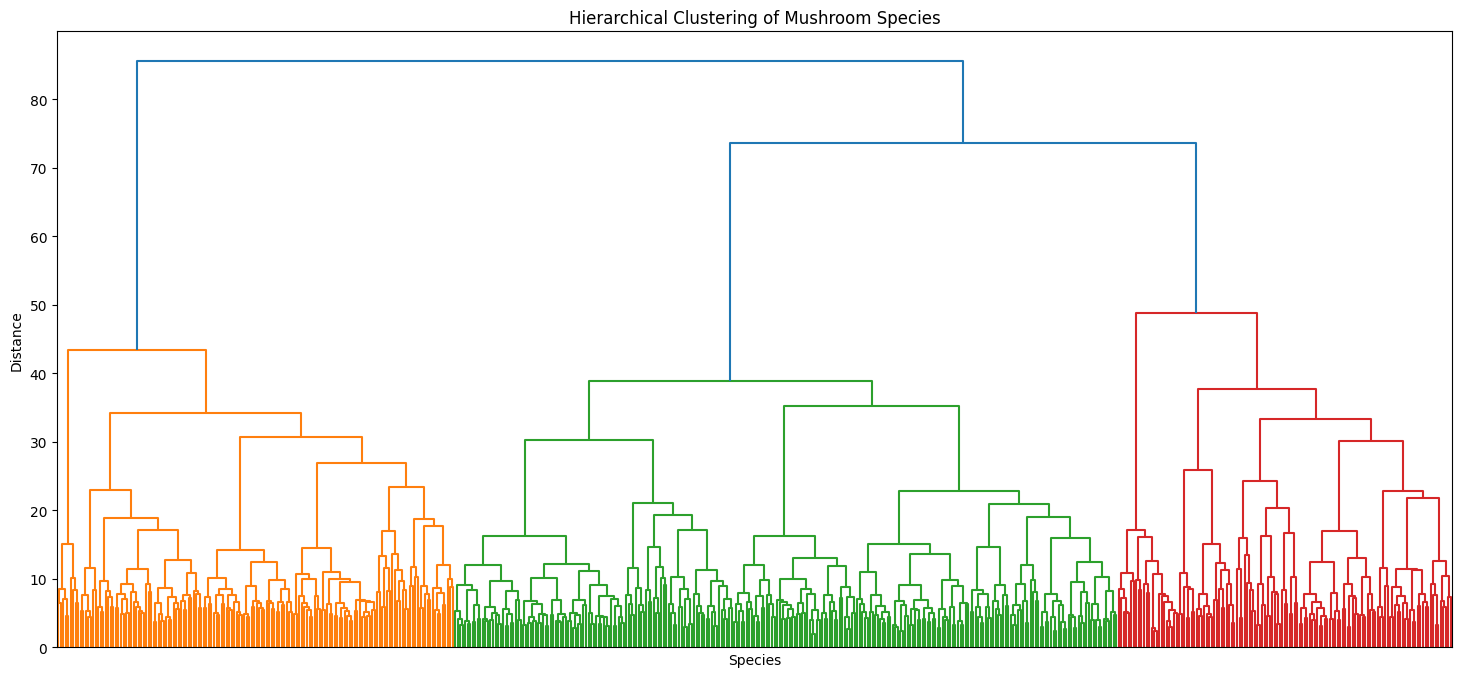

In [33]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(species_embeddings, method="ward")

plt.figure(figsize=(18, 8))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=None
)

plt.title("Hierarchical Clustering of Mushroom Species")
plt.xlabel("Species")
plt.ylabel("Distance")
plt.show()

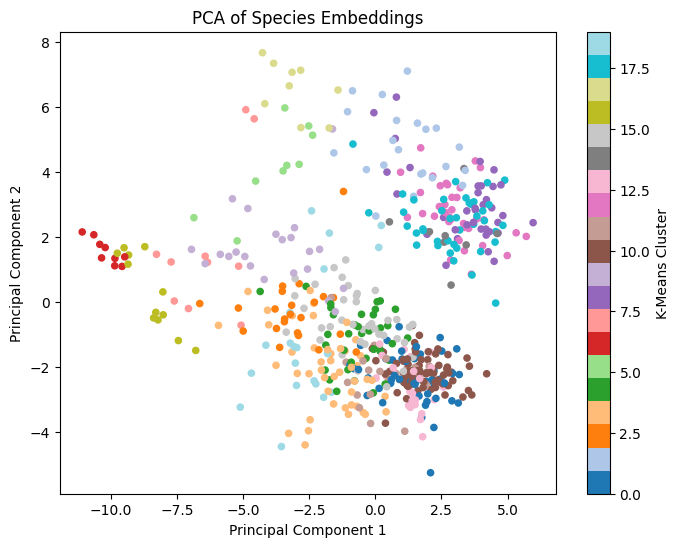

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_pca[:, 0],
    embedding_pca[:, 1],
    c=kmeans_clusters,
    cmap="tab20",
    s=20
)

plt.title("PCA of Species Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="K-Means Cluster")
plt.show()

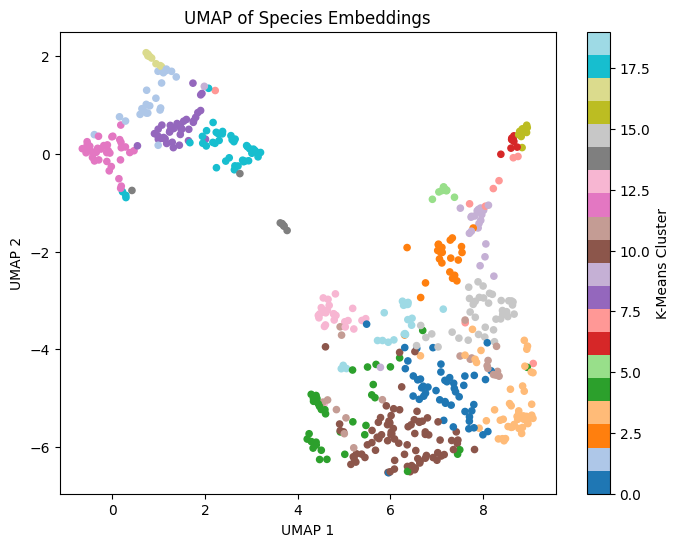

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_umap[:, 0],
    embedding_umap[:, 1],
    c=kmeans_clusters,
    cmap="tab20",
    s=20
)

plt.title("UMAP of Species Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="K-Means Cluster")
plt.show()

### Comparing Clusters

In [36]:
cluster_results = species_embeddings.copy()

cluster_results["Agglomerative"] = agg_clusters
cluster_results["KMeans"] = kmeans_clusters

cluster_results.head()

,0,1,2,3,4,5,6,7,8,9,...,504,505,506,507,508,509,510,511,Agglomerative,KMeans
label,,,,,,,,,,,,,,,,,,,,,
0,0.641581,0.423239,0.558378,1.079590,0.732316,0.707837,0.533030,0.604729,0.689805,0.645508,...,1.747051,0.403470,0.843804,0.926658,0.822564,0.310018,1.250640,0.654151,11,10
1,0.774870,0.417319,0.685024,0.972998,0.663994,0.796123,0.680969,0.599082,0.795399,0.754530,...,2.685983,0.463989,1.007971,1.035202,0.883684,0.464353,0.964801,0.560225,1,4
2,0.712695,0.451406,0.695645,1.488162,0.955559,0.816602,0.850002,0.553511,0.733584,0.483635,...,1.909559,0.424242,1.106223,0.842366,0.847117,0.290932,1.150743,0.466898,1,4
3,0.337549,0.399781,0.919717,0.359812,1.077749,0.271092,0.990493,1.046836,0.259625,0.749598,...,2.100396,0.293681,0.351937,1.303529,0.561449,0.209406,0.623459,0.449192,4,1
4,0.443474,0.396879,0.647044,0.546260,0.749056,0.638223,0.807196,0.728262,0.574111,0.757951,...,1.645075,0.141328,0.430812,0.643443,0.564100,0.224622,0.910482,0.484522,13,8


---

# Training and tuning model

### Train/val/test splits (70/15/15)

In [37]:
# split settings
random_state = SEED
train_size = 0.70
val_size = 0.15
test_size = 0.15

# ImageFolder numeric labels
targets = image_dataset.targets
indices = list(range(len(image_dataset)))

# split one: train and holdout
train_indices, holdout_indices, train_targets, holdout_targets = train_test_split(
    indices,
    targets,
    train_size=train_size,
    stratify=targets,
    random_state=random_state
)

# split two: holdout into validation/test
val_indices, test_indices = train_test_split(
    holdout_indices,
    test_size=test_size / (val_size + test_size),
    stratify=holdout_targets,
    random_state=random_state
)

# create PyTorch dataset subsets
train_dataset = Subset(image_dataset, train_indices)
val_dataset = Subset(image_dataset, val_indices)
test_dataset = Subset(image_dataset, test_indices)

print("train images:", len(train_dataset))
print("validation images:", len(val_dataset))
print("test images:", len(test_dataset))
print("total images:", len(train_dataset) + len(val_dataset) + len(test_dataset))

train images: 136787
validation images: 29312
test images: 29312
total images: 195411


### Dataloaders

In [38]:
# loader settings
batch_size = 32
num_workers = 0  # safer for Windows/Jupyter

# dataloaders for each split
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 4275
validation batches: 916
test batches: 916


### ResNet18 setup

In [39]:
# device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# number of folder-based classes
num_classes = len(image_dataset.classes)

# pretrained baseline CNN
model = models.resnet18(weights="DEFAULT")

# replace final layer for mushroom class count
model.fc = nn.Linear(model.fc.in_features, num_classes)

# move model to device
model = model.to(device)

print("device:", device)
print("number of classes:", num_classes)

device: cuda
number of classes: 555


### Baseline One epoch training

In [40]:
# freeze pretrained ResNet18 layers
for param in model.parameters():
    param.requires_grad = False

# train only the new final layer
for param in model.fc.parameters():
    param.requires_grad = True

# loss function for multiclass classification
criterion = nn.CrossEntropyLoss()

# optimizer only updates final layer
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# check trainable parameter count
trainable_params = sum(
    param.numel() for param in model.parameters() if param.requires_grad
)

print("trainable parameters:", trainable_params)

trainable parameters: 284715


In [41]:
# one training epoch
model.train()

running_loss = 0
correct = 0
total = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)

    predictions = outputs.argmax(dim=1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

train_loss = running_loss / total
train_accuracy = correct / total

print("train loss:", train_loss)
print("train accuracy:", train_accuracy)

train loss: 3.2550018936308716
train accuracy: 0.337700220050151


### Baseline validation metrics

In [42]:
# validation performance after one training epoch
model.eval()

val_running_loss = 0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        val_correct += (predictions == labels).sum().item()
        val_total += labels.size(0)

val_loss = val_running_loss / val_total
val_accuracy = val_correct / val_total

print("validation loss:", val_loss)
print("validation accuracy:", val_accuracy)

validation loss: 2.639666680685818
validation accuracy: 0.41512008733624456


In [43]:
# save first baseline checkpoint
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": image_dataset.class_to_idx,
    "train_loss": train_loss,
    "train_accuracy": train_accuracy,
    "val_loss": val_loss,
    "val_accuracy": val_accuracy,
    "transform": "Resize(224,224) + ToTensor + ImageNet Normalize",
    "split": "70/15/15 stratified",
    "model": "ResNet18 pretrained, frozen backbone, trained final layer"
}, "baseline_resnet18_epoch1.pth")

In [47]:
# collect validation predictions
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# validation metrics
val_accuracy = accuracy_score(all_labels, all_predictions)
val_macro_f1 = f1_score(all_labels, all_predictions, average="macro")
val_weighted_f1 = f1_score(all_labels, all_predictions, average="weighted")

print("validation accuracy:", val_accuracy)
print("validation macro-F1:", val_macro_f1)
print("validation weighted-F1:", val_weighted_f1)

validation accuracy: 0.41512008733624456
validation macro-F1: 0.23604116495270597
validation weighted-F1: 0.3951862631561272


### Diagnostics

In [48]:
# per-class validation metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    labels=list(range(num_classes)),
    zero_division=0
)

# validation metrics by class label
class_metrics = pd.DataFrame({
    "class_index": list(range(num_classes)),
    "class_label": image_dataset.classes,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "val_support": support
})

# add total dataset image count per class
class_total_counts = (
    pd.Series(targets)
    .value_counts()
    .reindex(range(num_classes), fill_value=0)
)

class_metrics["total_images"] = class_metrics["class_index"].map(class_total_counts)

In [49]:
# best validation F1 scores with enough validation examples
class_metrics[class_metrics["val_support"] >= 20].sort_values("f1", ascending=False).head(10)

,class_index,class_label,precision,recall,f1,val_support,total_images
91,91,Artomyces pyxidatus,0.905556,0.853403,0.878706,191,1273
551,551,Xanthoria parietina,0.857300,0.894616,0.875561,873,5823
109,109,Calocera viscosa,0.837607,0.830508,0.834043,118,787
136,136,Clathrus ruber,0.865385,0.803571,0.833333,56,372
454,454,Rhytisma acerinum,0.826446,0.833333,0.829876,120,801
366,366,Morchella esculenta,0.903846,0.723077,0.803419,65,430
259,259,Hericium coralloides,0.776224,0.816176,0.795699,136,905
244,244,Gyromitra gigas,0.788288,0.802752,0.795455,218,1453
135,135,Cladonia stellaris,0.807692,0.777778,0.792453,54,358
479,479,Sarcoscypha austriaca,0.682927,0.884211,0.770642,95,632


In [50]:
# worst validation F1 scores among classes with reasonable validation support
class_metrics[class_metrics["val_support"] >= 20].sort_values("f1", ascending = True).head(10)

,class_index,class_label,precision,recall,f1,val_support,total_images
514,514,Tricholoma arvernense,0.0,0.0,0.0,36,239
518,518,Tricholoma fulvum,0.0,0.0,0.0,49,323
357,357,Lycoperdon pyriforme,0.0,0.0,0.0,45,300
214,214,Entoloma vernum,0.0,0.0,0.0,43,286
468,468,Russula mustelina,0.0,0.0,0.0,29,191
363,363,Melanoleuca cognata,0.0,0.0,0.0,37,250
286,286,Inocybe geophylla,0.0,0.0,0.0,43,282
371,371,Mycena galopus,0.0,0.0,0.0,43,290
429,429,Pluteus cervinus,0.0,0.0,0.0,48,323
376,376,Mycena plumipes,0.0,0.0,0.0,35,235


In [51]:
# quick check: are larger classes performing better?
class_metrics[["total_images", "val_support", "f1"]].corr()

,total_images,val_support,f1
total_images,1.000000,0.999990,0.455647
val_support,0.999990,1.000000,0.455653
f1,0.455647,0.455653,1.000000


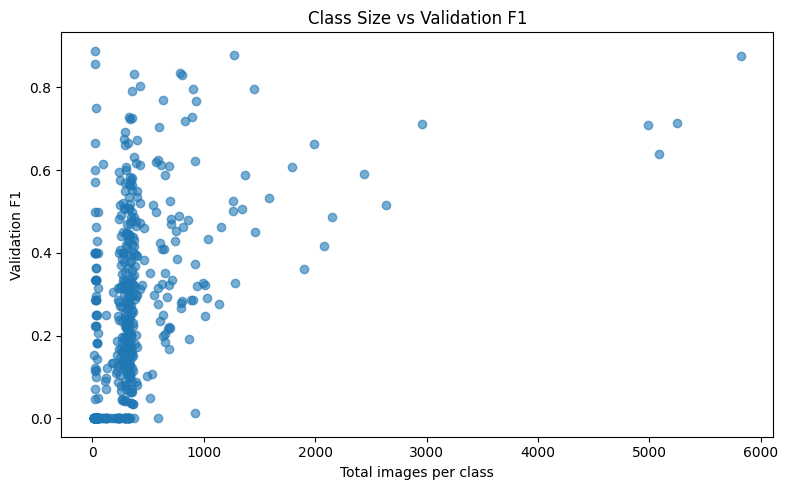

In [52]:
# Does more images improve performance?
plt.figure(figsize=(8, 5))

plt.scatter(
    class_metrics["total_images"],
    class_metrics["f1"],
    alpha=0.6
)

plt.title("Class Size vs Validation F1")
plt.xlabel("Total images per class")
plt.ylabel("Validation F1")
plt.tight_layout()
plt.show()

- More images show a trend in improvement of the f1 score, but does not guarantee.
- There are a number of medium-size classes which have F1 = 0, so class imbalance is only part of the issue. (class-size plays a role but doesn't explain the performance)

In [53]:
# collect validation predictions with confidence scores
model.eval()

val_file_paths = [image_dataset.samples[i][0] for i in val_indices]

all_labels = []
all_predictions = []
all_confidences = []
all_true_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)
        true_probs = probabilities[range(labels.size(0)), labels]

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())
        all_true_probs.extend(true_probs.cpu().numpy())

In [54]:
# validation prediction diagnostics table
val_diagnostics = pd.DataFrame({
    "file_path": val_file_paths,
    "true_index": all_labels,
    "predicted_index": all_predictions,
    "confidence": all_confidences,
    "true_class_probability": all_true_probs
})

val_diagnostics["true_label"] = val_diagnostics["true_index"].map(
    dict(enumerate(image_dataset.classes))
)

val_diagnostics["predicted_label"] = val_diagnostics["predicted_index"].map(
    dict(enumerate(image_dataset.classes))
)

val_diagnostics["correct"] = (
    val_diagnostics["true_index"] == val_diagnostics["predicted_index"]
)

# most confident wrong predictions
confident_wrong = (
    val_diagnostics[val_diagnostics["correct"] == False]
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

confident_wrong.head(20)

,file_path,true_index,predicted_index,confidence,true_class_probability,true_label,predicted_label,correct
0,images\Amanita persicina\Amanita persicina_241...,61,54,0.999551,0.000439,Amanita persicina,Amanita muscaria,False
1,images\Fomitopsis mounceae\Fomitopsis mounceae...,222,223,0.997958,0.000238,Fomitopsis mounceae,Fomitopsis pinicola,False
2,images\Amanita persicina\Amanita persicina_333...,61,54,0.997935,0.001879,Amanita persicina,Amanita muscaria,False
3,images\Amanita persicina\Amanita persicina_199...,61,54,0.997712,0.001702,Amanita persicina,Amanita muscaria,False
4,images\Helvella lacunosa\Helvella lacunosa_22....,255,194,0.996828,0.000773,Helvella lacunosa,Craterellus cornucopioides,False
5,images\Amanita hongoi\Amanita hongoi_16.webp,50,54,0.996520,0.000003,Amanita hongoi,Amanita muscaria,False
6,images\Cyclocybe aegerita\Cyclocybe aegerita_3...,200,280,0.995385,0.000007,Cyclocybe aegerita,Hypsizygus tessellatus,False
7,images\Phaeophyscia orbicularis\Phaeophyscia o...,405,551,0.995355,0.002143,Phaeophyscia orbicularis,Xanthoria parietina,False
8,images\Physcia adscendens\Physcia adscendens_1...,421,551,0.994990,0.000420,Physcia adscendens,Xanthoria parietina,False
9,images\Evernia prunastri\Evernia prunastri_222...,216,551,0.994339,0.000009,Evernia prunastri,Xanthoria parietina,False


### Confident but Wrong ; Image Audit

In [55]:
# visualize examples from one true/predicted confusion pair
def plot_confusion_pair(true_label, predicted_label, n=12, confidence_order="desc"):
    pair_examples = val_diagnostics[
        (val_diagnostics["true_label"] == true_label) &
        (val_diagnostics["predicted_label"] == predicted_label)
    ]

    # order by confidence or randomly sample
    if confidence_order == "desc":
        pair_examples = pair_examples.sort_values("confidence", ascending=False).head(n)
    elif confidence_order == "asc":
        pair_examples = pair_examples.sort_values("confidence", ascending=True).head(n)
    elif confidence_order is None:
        pair_examples = pair_examples.sample(
            n=min(n, len(pair_examples)),
            random_state=SEED
        )
    else:
        raise ValueError("confidence_order must be 'desc', 'asc', or None")

    # stop if no matching examples exist
    if len(pair_examples) == 0:
        print("No examples found for this true/predicted pair.")
        return

    # plot layout
    cols = 4
    rows = math.ceil(len(pair_examples) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = axes.flatten()

    # plot each image with prediction info
    for ax, (_, row) in zip(axes, pair_examples.iterrows()):
        img = Image.open(row["file_path"]).convert("RGB")
        result = "Correct" if row["correct"] else "Wrong"

        ax.imshow(img)
        ax.set_title(
            f"{result}\n"
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Conf: {row['confidence']:.3f}",
            fontsize=8
        )
        ax.axis("off")

    # hide unused plot slots
    for ax in axes[len(pair_examples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

- confidence_order = "desc" high confidence first
- confidence_order = "asc" low confidence first
- confidence_order = None random assortment

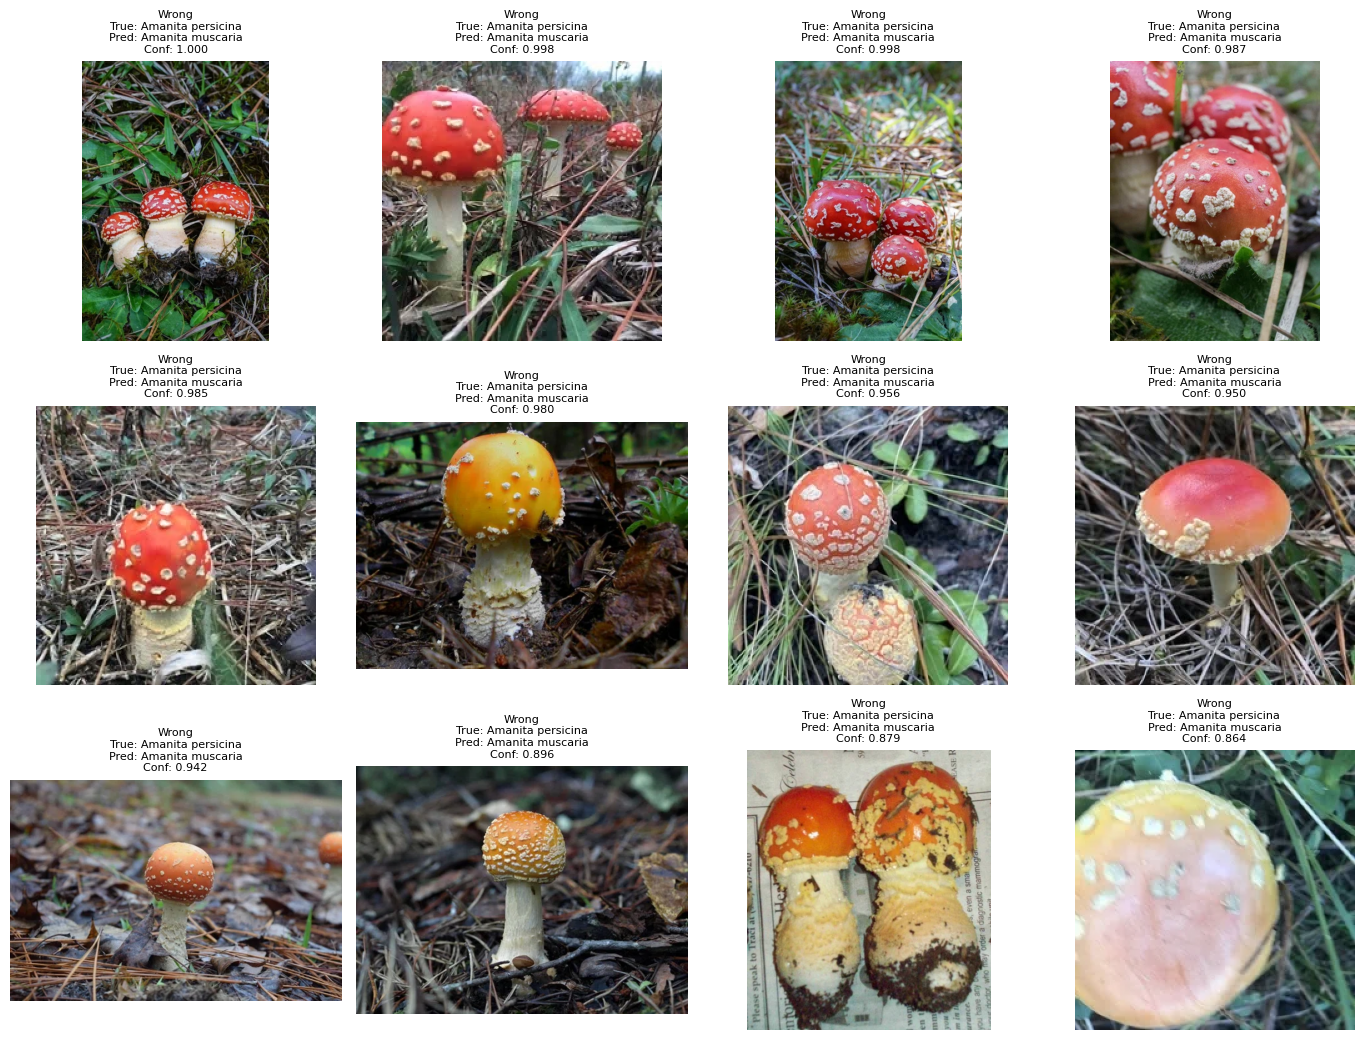

In [56]:
# highest-confidence mistakes
plot_confusion_pair("Amanita persicina", "Amanita muscaria", confidence_order="desc")

### Diagnostic Observation --> decision

- confident wrong lookalikes --> unfreeze final ResNet block
- zero f1-classes --> class weighting or more epochs
- f1 correlation with image count --> imbalance matters
- scattered incorrect predictions --> class not learned yet
- obscured and tiny mushrooms in photos --> targeted quality audit


---

# CNN experiments

#### Helper

In [57]:
# build ResNet18 classifier for this dataset
def build_resnet18_classifier(num_classes, device):
    model = models.resnet18(weights="DEFAULT")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)
    return model


# train one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    return train_loss, train_accuracy


# evaluate model on a given loader
def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    total = len(all_labels)

    loss = running_loss / total
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")
    weighted_f1 = f1_score(all_labels, all_predictions, average="weighted")

    return loss, accuracy, macro_f1, weighted_f1


# freeze all layers except final classifier
def freeze_backbone_train_fc(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.fc.parameters():
        param.requires_grad = True

    return model


# unfreeze layer4 and final classifier
def unfreeze_layer4_train_fc(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model

### Experiment 1: continue the same frozen-backbone ResNet18 for up to 5 total epochs.

In [58]:
# experiment 1 cache files
frozen_checkpoint_file = Path("baseline_resnet18_best_macro_f1.pth")
frozen_history_file = Path("baseline_resnet18_frozen_history.parquet")

# experiment 1 settings
max_epochs = 5
patience = 2

if frozen_checkpoint_file.exists() and frozen_history_file.exists():
    # load cached experiment 1
    checkpoint = torch.load(frozen_checkpoint_file, map_location=device)

    model = build_resnet18_classifier(num_classes, device)
    model.load_state_dict(checkpoint["model_state_dict"])

    experiment_history_df = pd.read_parquet(frozen_history_file)

    print("loaded frozen-backbone experiment")
    print("checkpoint:", frozen_checkpoint_file)
    print("history:", frozen_history_file)

else:
    # start history with already-completed epoch 1
    experiment_history = [{
        "experiment": "frozen_backbone_fc_only",
        "epoch": 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1
    }]

    # epoch 1 starts as current best
    best_val_macro_f1 = val_macro_f1
    best_epoch = 1
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    # continue training from epoch 2
    for epoch in range(2, max_epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_accuracy, val_macro_f1, val_weighted_f1 = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        experiment_history.append({
            "experiment": "frozen_backbone_fc_only",
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_macro_f1,
            "val_weighted_f1": val_weighted_f1
        })

        print("epoch:", epoch)
        print("train accuracy:", train_accuracy)
        print("validation accuracy:", val_accuracy)
        print("validation macro-F1:", val_macro_f1)

        # track best model by validation macro-F1
        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            print("new best frozen model")

        else:
            epochs_without_improvement += 1
            print("epochs without improvement:", epochs_without_improvement)

        if epochs_without_improvement >= patience:
            print("early stopping triggered")
            break

    # save full experiment history
    experiment_history_df = pd.DataFrame(experiment_history)
    experiment_history_df.to_parquet(frozen_history_file)
    experiment_history_df.to_csv("baseline_resnet18_frozen_history.csv", index=False)

    # save best frozen model
    torch.save({
        "model_state_dict": best_model_state,
        "class_to_idx": image_dataset.class_to_idx,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro_f1,
        "history": experiment_history,
        "model": "ResNet18 pretrained, frozen backbone, trained final layer",
        "transform": "Resize(224,224) + ToTensor + ImageNet Normalize",
        "split": "70/15/15 stratified",
        "selection_metric": "validation macro-F1"
    }, frozen_checkpoint_file)

    # reload best frozen model into memory
    model.load_state_dict(best_model_state)

    print("saved frozen-backbone experiment")
    print("best epoch:", best_epoch)
    print("best validation macro-F1:", best_val_macro_f1)

experiment_history_df

epoch: 2
train accuracy: 0.4363207029907813
validation accuracy: 0.43995633187772926
validation macro-F1: 0.27651345860202475
new best frozen model
epoch: 3
train accuracy: 0.4651246097947904
validation accuracy: 0.4421738537117904
validation macro-F1: 0.29011300620420555
new best frozen model
epoch: 4
train accuracy: 0.47993595882649664
validation accuracy: 0.45083924672489084
validation macro-F1: 0.29761855987805547
new best frozen model
epoch: 5
train accuracy: 0.4932193848830664
validation accuracy: 0.44916757641921395
validation macro-F1: 0.3078329496778672
new best frozen model
saved frozen-backbone experiment
best epoch: 5
best validation macro-F1: 0.3078329496778672


,experiment,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,frozen_backbone_fc_only,1,3.255002,0.337700,2.639667,0.415120,0.236041,0.395186
1,frozen_backbone_fc_only,2,2.487179,0.436321,2.512749,0.439956,0.276513,0.425408
2,frozen_backbone_fc_only,3,2.311683,0.465125,2.518463,0.442174,0.290113,0.429422
3,frozen_backbone_fc_only,4,2.217657,0.479936,2.497614,0.450839,0.297619,0.436693
4,frozen_backbone_fc_only,5,2.150091,0.493219,2.521972,0.449168,0.307833,0.446239


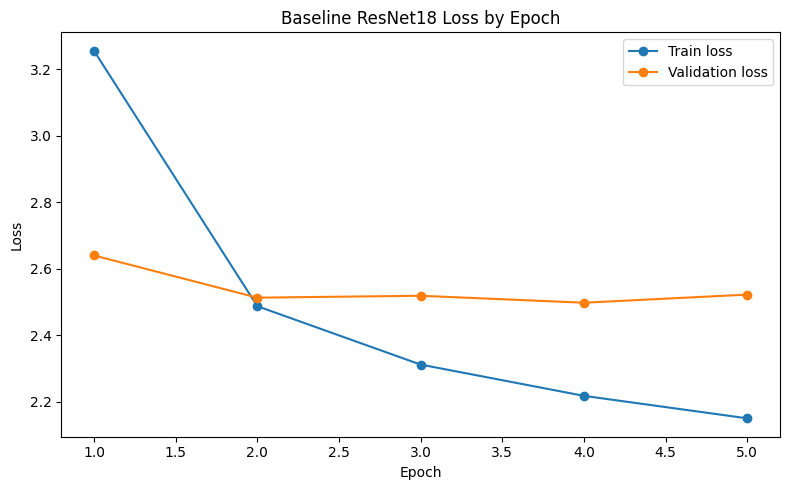

In [59]:
# plot loss curves
plt.figure(figsize=(8, 5))

plt.plot(experiment_history_df["epoch"], experiment_history_df["train_loss"], marker="o", label="Train loss")
plt.plot(experiment_history_df["epoch"], experiment_history_df["val_loss"], marker="o", label="Validation loss")

plt.title("Baseline ResNet18 Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

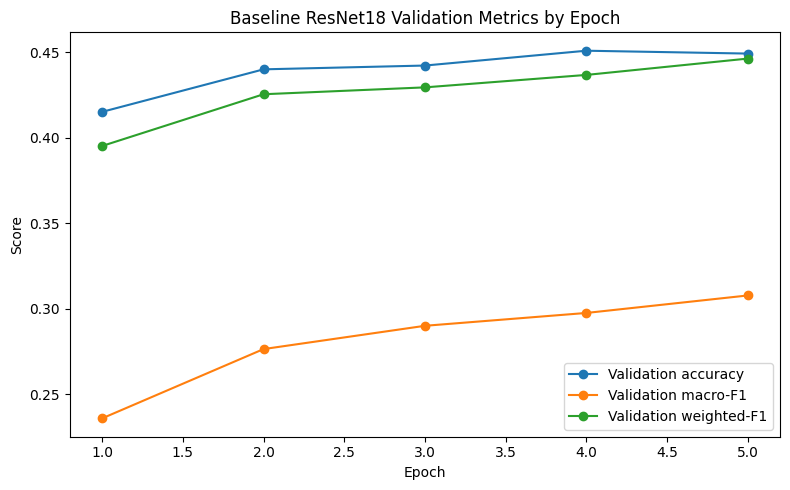

In [60]:
# plot validation metrics
plt.figure(figsize=(8, 5))

plt.plot(experiment_history_df["epoch"], experiment_history_df["val_accuracy"], marker="o", label="Validation accuracy")
plt.plot(experiment_history_df["epoch"], experiment_history_df["val_macro_f1"], marker="o", label="Validation macro-F1")
plt.plot(experiment_history_df["epoch"], experiment_history_df["val_weighted_f1"], marker="o", label="Validation weighted-F1")

plt.title("Baseline ResNet18 Validation Metrics by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

### Experiment 2: unfreeze layer 4 + final layer

In [61]:
# experiment 2 cache files
layer4_checkpoint_file = Path("resnet18_layer4_finetune_epoch2_selected.pth")
layer4_history_file = Path("fine_tune_layer4_epoch2_selected_history.parquet")

# experiment 2 settings
fine_tune_epochs = 2
fine_tune_lr = 0.0001

if layer4_checkpoint_file.exists() and layer4_history_file.exists():
    # load cached experiment 2
    checkpoint = torch.load(layer4_checkpoint_file, map_location=device)

    model = build_resnet18_classifier(num_classes, device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)

    selected_fine_tune_history_df = pd.read_parquet(layer4_history_file)

    print("loaded selected layer4 fine-tune experiment")
    print("checkpoint:", layer4_checkpoint_file)
    print("history:", layer4_history_file)

else:
    # load best frozen-backbone model as fair starting point
    frozen_checkpoint = torch.load(frozen_checkpoint_file, map_location=device)

    model = build_resnet18_classifier(num_classes, device)
    model.load_state_dict(frozen_checkpoint["model_state_dict"])
    model = model.to(device)

    # unfreeze layer4 and classifier head
    model = unfreeze_layer4_train_fc(model)

    optimizer = torch.optim.Adam(
        filter(lambda param: param.requires_grad, model.parameters()),
        lr=fine_tune_lr
    )

    selected_fine_tune_history = []

    for epoch in range(1, fine_tune_epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_accuracy, val_macro_f1, val_weighted_f1 = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        selected_fine_tune_history.append({
            "experiment": "layer4_finetune_epoch2_selected",
            "fine_tune_epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_macro_f1,
            "val_weighted_f1": val_weighted_f1,
            "learning_rate": fine_tune_lr
        })

        print("fine-tune epoch:", epoch)
        print("train accuracy:", train_accuracy)
        print("validation loss:", val_loss)
        print("validation accuracy:", val_accuracy)
        print("validation macro-F1:", val_macro_f1)

    selected_fine_tune_history_df = pd.DataFrame(selected_fine_tune_history)

    selected_fine_tune_history_df.to_parquet(layer4_history_file)
    selected_fine_tune_history_df.to_csv(
        "fine_tune_layer4_epoch2_selected_history.csv",
        index=False
    )

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_to_idx": image_dataset.class_to_idx,
        "fine_tune_epoch": fine_tune_epochs,
        "history": selected_fine_tune_history,
        "model": "ResNet18 pretrained, layer4 + fc fine-tuned",
        "transform": "Resize(224,224) + ToTensor + ImageNet Normalize",
        "split": "70/15/15 stratified",
        "learning_rate": fine_tune_lr,
        "selection_reason": "Selected epoch 2 due to lower validation loss and smaller train/validation gap than epoch 3."
    }, layer4_checkpoint_file)

    print("saved selected layer4 fine-tune experiment")

selected_fine_tune_history_df

fine-tune epoch: 1
train accuracy: 0.594376658600598
validation loss: 1.5514895001092852
validation accuracy: 0.6071915938864629
validation macro-F1: 0.461922280523534
fine-tune epoch: 2
train accuracy: 0.7336735216065854
validation loss: 1.5076956897974014
validation accuracy: 0.6233624454148472
validation macro-F1: 0.4750851546122945
saved selected layer4 fine-tune experiment


,experiment,fine_tune_epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,learning_rate
0,layer4_finetune_epoch2_selected,1,1.594520,0.594377,1.551490,0.607192,0.461922,0.599932,0.0001
1,layer4_finetune_epoch2_selected,2,0.975829,0.733674,1.507696,0.623362,0.475085,0.617683,0.0001


- Fine-tuning began to show overfitting signs by epoch 3 because validation loss increased while training accuracy rose sharply.
- Macro F1 has best performance on third epoch, which is better for the minor classes
- However, epoch two did the best here since the priority is lowest validation loss/less-overconfidence
- Further training should use regularization, lower learning rate, or early stopping.